# **<span style="color:#682F2F;"><center>LABELLED DIMENSIONS OF A DIAMOND</center></span>**

![Diamond anatomy.jpg](attachment:d217a1de-e1c5-4c73-8795-7bdfe8545fd2.jpg)

<div style="border-radius:10px;
            border : #682F2F solid;
            background-color:#FFF8DC;
           font-size:110%;
            text-align: left">
    
## <h2 style='border:0; color:#682F2F'><center>About the data (Description of attributes)</center></h2>

**This classic dataset contains the prices and other attributes of almost 54,000 diamonds. There are 10 attributes included in the dataset including the target ie. price.**

* **carat (0.2-5.01):** The carat is the diamond’s physical weight measured in metric carats. One carat equals 0.20 gram and is subdivided into 100 points. 
* **cut (Fair, Good, Very Good, Premium, Ideal):** The quality of the cut. The more precise the diamond is cut, the more captivating the diamond is to the eye thus of high grade. 
* **color (from J (worst) to D (best)):** The colour of gem-quality diamonds occurs in many hues. In the range from colourless to light yellow or light brown. Colourless diamonds are the rarest. Other natural colours (blue, red, pink for example) are known as "fancy,” and their colour grading is different than from white colorless diamonds. 
* **clarity (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best)):** Diamonds can have internal characteristics known as inclusions or external characteristics known as blemishes. Diamonds without inclusions or blemishes are rare; however, most characteristics can only be seen with magnification. 
* **depth (43-79)**: It is the total depth percentage which equals to z / mean(x, y) = 2 * z / (x + y). The depth of the diamond is its height (in millimetres) measured from the culet (bottom tip) to the table (flat, top surface) as referred in the labelled diagram above. 
* **table (43-95):** It is the width of the top of the diamond relative to widest point. It gives diamond stunning fire and brilliance by reflecting lights to all directions which when seen by an observer, seems lustrous. 
* **price ($$326 - $18826):** It is the price of the diamond in US dollars. **It is our very target column in the dataset.**
* **x (0 - 10.74):** Length of the diamond (in mm) 
* **y (0 - 58.9):** Width of the diamond (in mm) 
* **z (0 - 31.8):** Depth of the diamond (in mm) 

<a id = "title-one"><a>
<h1 style='background:#682F2F; border:0; border-radius: 10px; color:white'><center>IMPORTING LIBRARIES<center><h1>

In [2]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement xgboost (from versions: none)
ERROR: No matching distribution found for xgboost


In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn. linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
# from xgboost import XGBRegressor

from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn import metrics 
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score, root_mean_squared_error

<a id = "title-two"></a>
<h1 style='background:#682F2F; border:0; border-radius: 10px; color:white'><center>LOADING DATA</center></h1>

In [6]:
data_df = pd.read_csv("C:/Users/bianc/OneDrive/Documents/1-Estudos/2-DNC/1-Data Science/1-Material/Materis9-Modelos_de_Classificacao_Regressao/IA para Ciência de Dados/diamonds.csv")
data_df.sample(10)  

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
43867,43868,0.50,Ideal,H,VS1,60.5,57.0,1449,5.15,5.19,3.13
683,684,0.80,Very Good,F,SI1,63.4,57.0,2851,5.89,5.82,3.71
5811,5812,0.91,Premium,E,SI1,61.5,60.0,3911,6.19,6.24,3.82
5869,5870,0.92,Fair,H,VS1,56.0,60.0,3924,6.53,6.51,3.65
5919,5920,0.94,Very Good,F,SI2,62.6,57.0,3938,6.25,6.27,3.92
47906,47907,0.53,Ideal,G,VVS2,62.5,54.0,1914,5.21,5.19,3.25
40359,40360,0.43,Ideal,D,VS2,60.7,57.0,1129,4.91,4.88,2.97
45447,45448,0.52,Good,E,VS2,58.3,61.0,1673,5.26,5.31,3.08
24569,24570,1.01,Ideal,E,IF,61.4,57.0,12865,6.53,6.46,3.99
46014,46015,0.53,Premium,G,VS1,63.0,58.0,1727,5.17,5.15,3.25


<a id = "title-three"></a>
<h1 style='background: #682F2F; border:0; border-radius: 10px; color:white'><center>DATA ANALYSIS</center></h1>

### **<span style="color:#682F2F;"><center>Checking for missing values & categorical variables</center></span>**

In [7]:
# Checking for missing values and categorical variables in the dataset
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


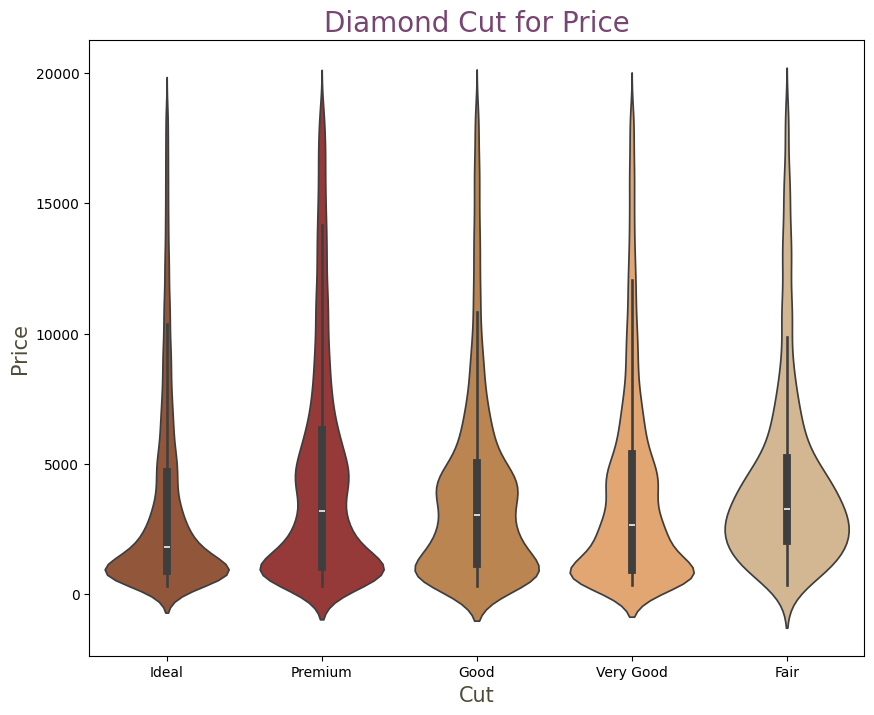

In [8]:
plt.figure(figsize=(10,8))
cols = ["#A0522D","#A52A2A","#CD853F","#F4A460","#DEB887"]
ax = sns.violinplot(x="cut",y="price", data=data_df, palette=cols,scale= "count")
ax.set_title("Diamond Cut for Price", color="#774571", fontsize = 20)
ax.set_ylabel("Price", color="#4e4c39", fontsize = 15)
ax.set_xlabel("Cut", color="#4e4c39", fontsize = 15)
plt.show()